In [1]:
import numpy as np

def read_velocity_fields(filename, nx=100, N=10):
    """
    Read first N time steps from velocity file.
    Returns:
        x, y      → (nx, nx)
        ux, uy    → (N, nx, nx)
    """
    ux = np.zeros((N, nx, nx))
    uy = np.zeros((N, nx, nx))
    x = np.zeros((nx, nx))
    y = np.zeros((nx, nx))

    with open(filename, 'r') as f:
        for n in range(N):
            for i in range(nx):
                for j in range(nx):
                    line = f.readline()
                    if not line:
                        raise EOFError("File ended before reaching N time steps")

                    xx, yy, uxx, uyy = map(float, line.split())

                    # reproduce Fortran indexing:
                    # x(i,nx+1-j)
                    jj = nx - 1 - j
                    x[i, jj] = xx
                    y[i, jj] = yy
                    ux[n, i, jj] = uxx
                    uy[n, i, jj] = uyy

    return x, y, ux, uy

In [20]:
nx=100
N=20

x, y, ux, uy = read_velocity_fields("./data/ExpB/ExpB-merged.dat", nx=nx, N=N)
_, _, ux_fluc, uy_fluc = read_velocity_fields("./data/ExpB/ExpB-nomean-merged.dat", nx=nx, N=N)

u_mean = ux.mean(axis=0)
v_mean = uy.mean(axis=0)

u_fluc_mean = ux_fluc.mean(axis=0)
v_fluc_mean = uy_fluc.mean(axis=0)

Mask outside radius > 0.49m

In [21]:
xc = np.mean(x)
yc = np.mean(y)
R = 0.49

r = np.sqrt((x - xc)**2 + (y - yc)**2)
mask = r <= R

u_mean = np.where(mask, u_mean, np.nan)
v_mean = np.where(mask, v_mean, np.nan)

u_fluc_mean = np.where(mask, u_fluc_mean, np.nan)
v_fluc_mean = np.where(mask, v_fluc_mean, np.nan)

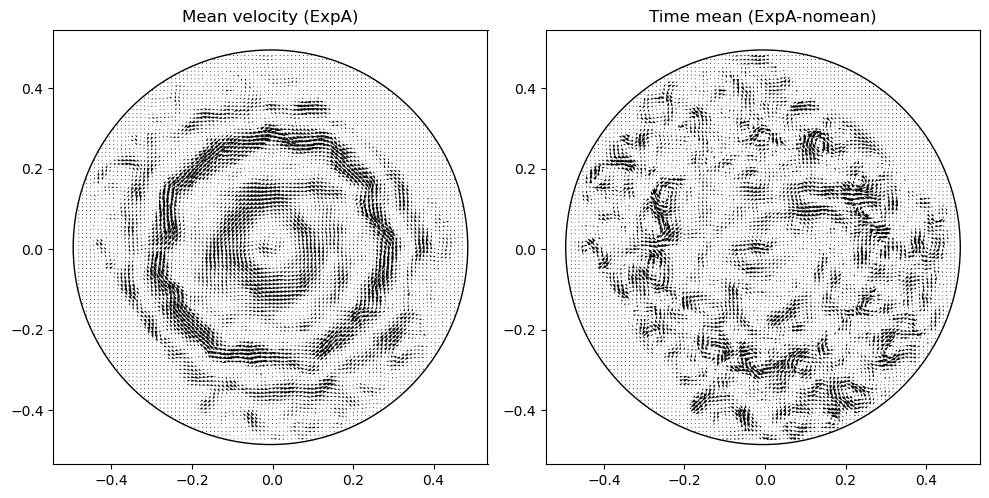

In [22]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

step = 1

fig, axes = plt.subplots(1, 2, figsize=(10,5))

# ---- Panel 1: original mean ----
axes[0].quiver(
    x[::step, ::step],
    y[::step, ::step],
    u_mean[::step, ::step],
    v_mean[::step, ::step],
    scale=None
)
axes[0].add_patch(Circle((xc, yc), R, edgecolor='k', facecolor='none'))
axes[0].set_title("Mean velocity (ExpA)")
axes[0].set_aspect('equal')

# ---- Panel 2: nomean mean ----
axes[1].quiver(
    x[::step, ::step],
    y[::step, ::step],
    u_fluc_mean[::step, ::step],
    v_fluc_mean[::step, ::step],
    scale=None
)
axes[1].add_patch(Circle((xc, yc), R, edgecolor='k', facecolor='none'))
axes[1].set_title("Time mean (ExpA-nomean)")
axes[1].set_aspect('equal')

plt.tight_layout()
plt.show()

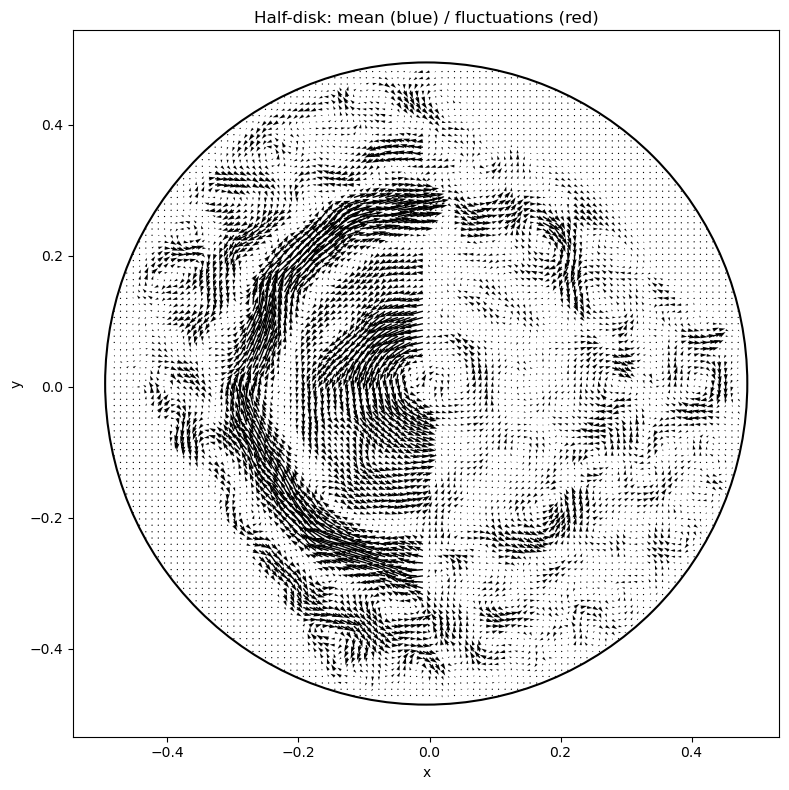

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

# Parameters
N = 50
nx = 100
step = 1
R = 0.49

# Load data
x, y, ux, uy = read_velocity_fields("./data/ExpA/ExpA-merged.dat", nx=nx, N=N)
_, _, ux_fluc, uy_fluc = read_velocity_fields("./data/ExpA/ExpA-nomean-merged.dat", nx=nx, N=N)

# Time averages
u_mean = ux.mean(axis=0)
v_mean = uy.mean(axis=0)
u_fluc_mean = ux_fluc.mean(axis=0)
v_fluc_mean = uy_fluc.mean(axis=0)

# Compute center
xc = np.mean(x)
yc = np.mean(y)
r = np.sqrt((x - xc)**2 + (y - yc)**2)

# Disk mask
disk_mask = r <= R

# Half-disk masks
left_mask = disk_mask & (x <= xc)   # left half
right_mask = disk_mask & (x > xc)   # right half

# Apply masks
u_mean_masked = np.where(left_mask, u_mean, np.nan)
v_mean_masked = np.where(left_mask, v_mean, np.nan)

u_fluc_masked = np.where(right_mask, u_fluc_mean, np.nan)
v_fluc_masked = np.where(right_mask, v_fluc_mean, np.nan)

# Plot
fig, ax = plt.subplots(figsize=(8,8))

# Left half: mean
ax.quiver(
    x[::step, ::step],
    y[::step, ::step],
    u_mean_masked[::step, ::step],
    v_mean_masked[::step, ::step],
    color='k', scale=2,
    width=0.002
)

# Right half: fluctuations
ax.quiver(
    x[::step, ::step],
    y[::step, ::step],
    u_fluc_masked[::step, ::step],
    v_fluc_masked[::step, ::step],
    color='k', scale=2,
    width=0.002
)

# Circle outline
circle = Circle((xc, yc), R, edgecolor='k', facecolor='none', linewidth=1.5)
ax.add_patch(circle)

ax.set_aspect('equal')
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Half-disk: mean (blue) / fluctuations (red)")
plt.tight_layout()
plt.show()

/tmp/ipykernel_16306/3144009387.py:60: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('RdBu_r').copy()


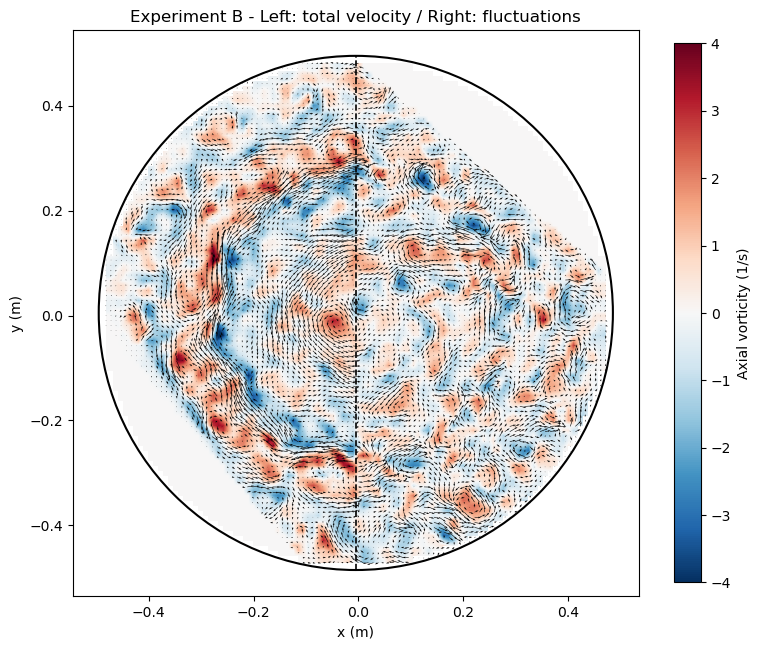

In [143]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import matplotlib.cm as cm
import numpy.ma as ma

# Parameters
N = 8 #time step 0.05s, period 0.8s, so 16 timesteps for one rotation
nx = 100
step = 1
R = 0.49

# Load data
x, y, ux, uy = read_velocity_fields("./data/ExpB/ExpB-merged.dat", nx=nx, N=N)
_, _, ux_fluc, uy_fluc = read_velocity_fields("./data/ExpB/ExpB-nomean-merged.dat", nx=nx, N=N)

# Time averages
u_mean = ux.mean(axis=0)
v_mean = uy.mean(axis=0)
u_fluc_mean = ux_fluc.mean(axis=0)
v_fluc_mean = uy_fluc.mean(axis=0)

# Compute center
xc = np.mean(x)
yc = np.mean(y)
r = np.sqrt((x - xc)**2 + (y - yc)**2)

# Disk mask
disk_mask = r <= R
left_mask = disk_mask & (x <= xc) & (y >= (-0.6 - 1.2*x))
right_mask = disk_mask & (x > xc) & (y <= (0.485 - 0.85*x))

# Compute gradients on **full fields**
dx = x[1,0] - x[0,0]
dy = y[0,1] - y[0,0]

vorticity_left = np.gradient(v_mean, axis=0)/dx - np.gradient(u_mean, axis=1)/dy
vorticity_right = np.gradient(v_fluc_mean, axis=0)/dx - np.gradient(u_fluc_mean, axis=1)/dy

# Apply half-disk masks AFTER computing gradients
vorticity_left = np.where(left_mask, vorticity_left, np.nan)
vorticity_right = np.where(right_mask, vorticity_right, np.nan)

# Combine for plotting
vorticity = np.where(left_mask, vorticity_left, np.nan)
vorticity = np.where(right_mask, vorticity_right, vorticity)
vorticity0 = np.nan_to_num(vorticity, nan=0.0)
vorticity_masked = ma.masked_where(r > R, vorticity0)  # use your vorticity array

# Mask velocities for plotting
u_mean_masked = np.where(left_mask, u_mean, np.nan)
v_mean_masked = np.where(left_mask, v_mean, np.nan)
u_fluc_masked = np.where(right_mask, u_fluc_mean, np.nan)
v_fluc_masked = np.where(right_mask, v_fluc_mean, np.nan)

# Plot
fig, ax = plt.subplots(figsize=(8,8))

# Copy colormap and set masked values to white
cmap = cm.get_cmap('RdBu_r').copy()
cmap.set_bad(color='white')  # masked (outside circle) becomes white

# Background: vorticity
#c = ax.pcolormesh(x, y, vorticity, shading='auto', cmap='bwr')
c=ax.imshow(
    vorticity_masked.T,
    extent=[x.min(), x.max(), y.min(), y.max()],
    origin='lower',
    cmap=cmap,
    interpolation='bilinear',  # smooth
    aspect='equal',
    vmin=-4,
    vmax=4
)

fig.colorbar(c, ax=ax, label="Axial vorticity (1/s)",shrink=0.7)

# Quiver arrows
arrow_width = 0.001
arrow_scale = 2.5

ax.quiver(
    x[::step, ::step],
    y[::step, ::step],
    u_mean_masked[::step, ::step],
    v_mean_masked[::step, ::step],
    color='k', width=arrow_width, scale=arrow_scale
)

ax.quiver(
    x[::step, ::step],
    y[::step, ::step],
    u_fluc_masked[::step, ::step],
    v_fluc_masked[::step, ::step],
    color='k', width=arrow_width, scale=arrow_scale/1.5
)

# Circle outline
circle = Circle((xc, yc), R, edgecolor='k', facecolor='none', linewidth=1.5)
ax.add_patch(circle)
ax.plot([xc, xc], [yc - R, yc + R], color='k', linewidth=1.2, linestyle='--')

ax.set_aspect('equal')
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.set_title("Experiment B - Left: total velocity / Right: fluctuations")
plt.tight_layout()
plt.show()

In [144]:
save=True 

if save:
    output_path = f"../paper_RSTA25_Lemasquerier/output_figures/quiver_mean_fluct.pdf"
    fig.savefig(output_path, format='pdf', bbox_inches='tight')  # save as PDF
plt.show()